# Project 2: Reproducibility in Natural Language Processing

## Part 1: Data Loading and Initial Exploration (15 pts)

The data for this project is stored in the `data` folder in your repositories, in the `SOTU.csv` file. The data file is structured as a CSV with columns for president name, speech text, year, and word count in the speech. 

In this section you will:

1. Import the data into a pandas dataframe
2. Perform exploratory data analysis (EDA) including specifically:
- Analyze the number of speeches per president
- Analyze the number of speeches per year
- Analyze the word count distribution
- Analyze the word count distribution accross years using a rug plot
- Analyze the average word count per president
3. Write commentary on your findings

First, create the `conda` environment with the provided yaml file. Note, it's not unusual for it to take ~15 minutes for the environment to fully install.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

plt.style.use('seaborn-v0_8-dark')

In [4]:
sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


In [17]:
order  = sou["President"].unique()
speech_by_president = sou["President"].value_counts().reindex(order)

Text(0, 0.5, 'Count')

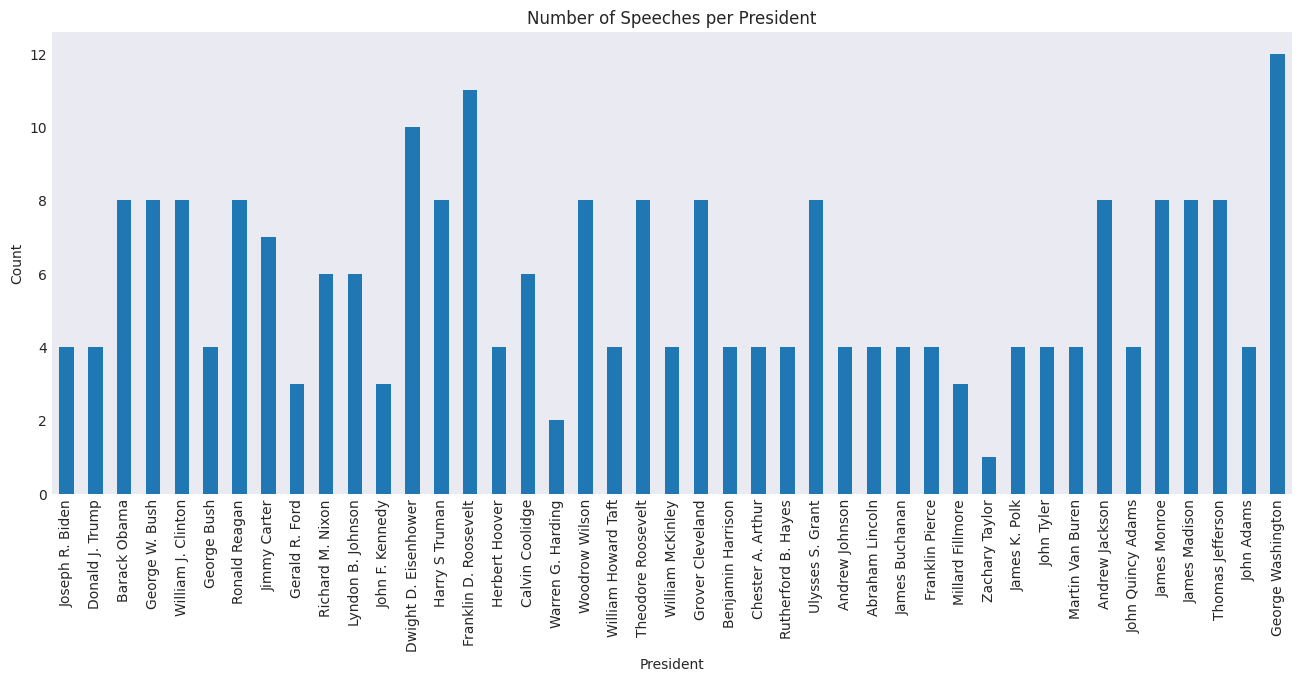

In [52]:
plt.figure(figsize=(16, 6))
speech_by_president.plot(kind="bar")
plt.title("Number of Speeches per President")
plt.ylabel("Count")

In [40]:
speech_by_year = sou.groupby("Year").size()
speech_by_year

Year
1790.0    4
1791.0    2
1792.0    2
1793.0    1
1794.0    1
         ..
2020.0    1
2021.0    1
2022.0    1
2023.0    1
2024.0    1
Length: 232, dtype: int64

Text(0.5, 1.0, 'Number of SOTU Speeches per Year')

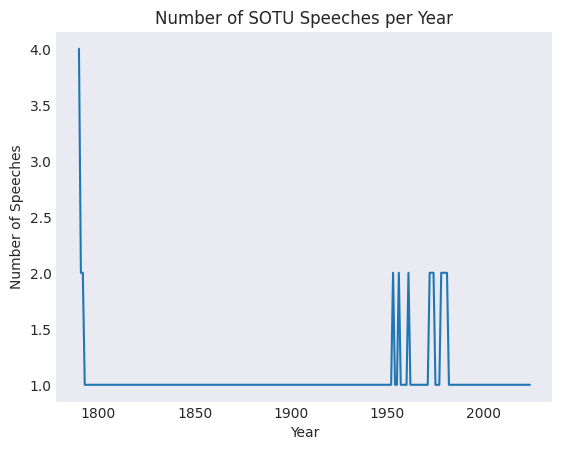

In [50]:
plt.plot(speech_by_year.index, speech_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Speeches")
plt.title("Number of SOTU Speeches per Year")

In [42]:
speech_by_wordcount = sou.groupby("Word Count").size()
speech_by_wordcount

Word Count
1055     2
1069     4
1353     1
1491     1
1815     1
        ..
24983    1
27183    1
27238    1
27312    1
33065    1
Length: 232, dtype: int64

Text(0.5, 1.0, 'Distribution of State of the Union Speech Word Counts')

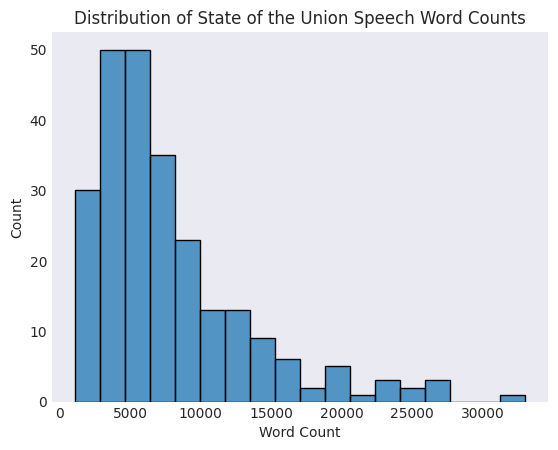

In [45]:
sns.histplot(sou["Word Count"])
plt.title("Distribution of State of the Union Speech Word Counts")

Text(0.5, 1.0, 'Speech Year Versus Word Count')

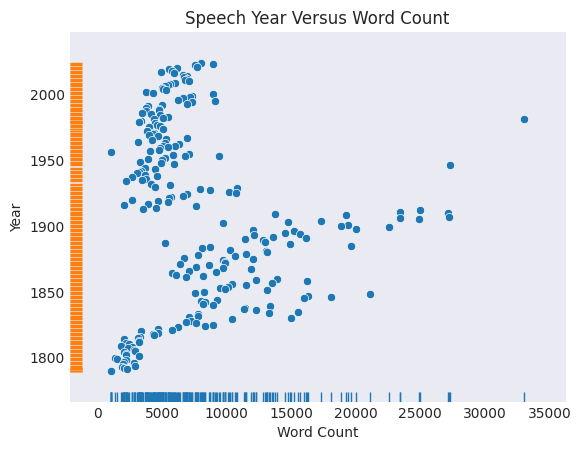

In [55]:
sns.scatterplot(x=sou["Word Count"], y=sou["Year"])
sns.rugplot(x=sou["Word Count"])
sns.rugplot(y=sou["Year"])
plt.title("Speech Year Versus Word Count")

In [57]:
speech_mean = sou.groupby("President")["Word Count"].mean().reindex(order)
speech_mean

President
Joseph R. Biden           8063.500000
Donald J. Trump           5586.500000
Barack Obama              6624.000000
George W. Bush            4971.750000
William J. Clinton        7457.625000
George Bush               4357.500000
Ronald Reagan             4482.875000
Jimmy Carter              7874.714286
Gerald R. Ford            4495.666667
Richard M. Nixon          4427.333333
Lyndon B. Johnson         4715.833333
John F. Kennedy           5555.000000
Dwight D. Eisenhower      4703.500000
Harry S Truman            8131.625000
Franklin D. Roosevelt     3476.090909
Herbert Hoover            6251.500000
Calvin Coolidge           8529.833333
Warren G. Harding         5612.500000
Woodrow Wilson            4311.625000
William Howard Taft      22335.750000
Theodore Roosevelt       19505.125000
William McKinley         18380.000000
Grover Cleveland         13798.250000
Benjamin Harrison        13507.500000
Chester A. Arthur        10031.250000
Rutherford B. Hayes      10784.000000
Ul